In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi
import matplotlib.cm as cm
import os

# Define the directory where the images are stored
image_dir = os.path.join(os.getcwd(), 'Figures')
print(f"Image directory: {image_dir}")
# Ensure the directory exists
if not os.path.exists(image_dir):
    os.makedirs(image_dir)

Image directory: c:\Users\User\OneDrive\Documentos\Teaching\PolEcon-Oxford2025\03 Simulations\Week3\Figures


C:\Users\User\AppData\Local\Temp\ipykernel_26096\4290103727.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(df4))


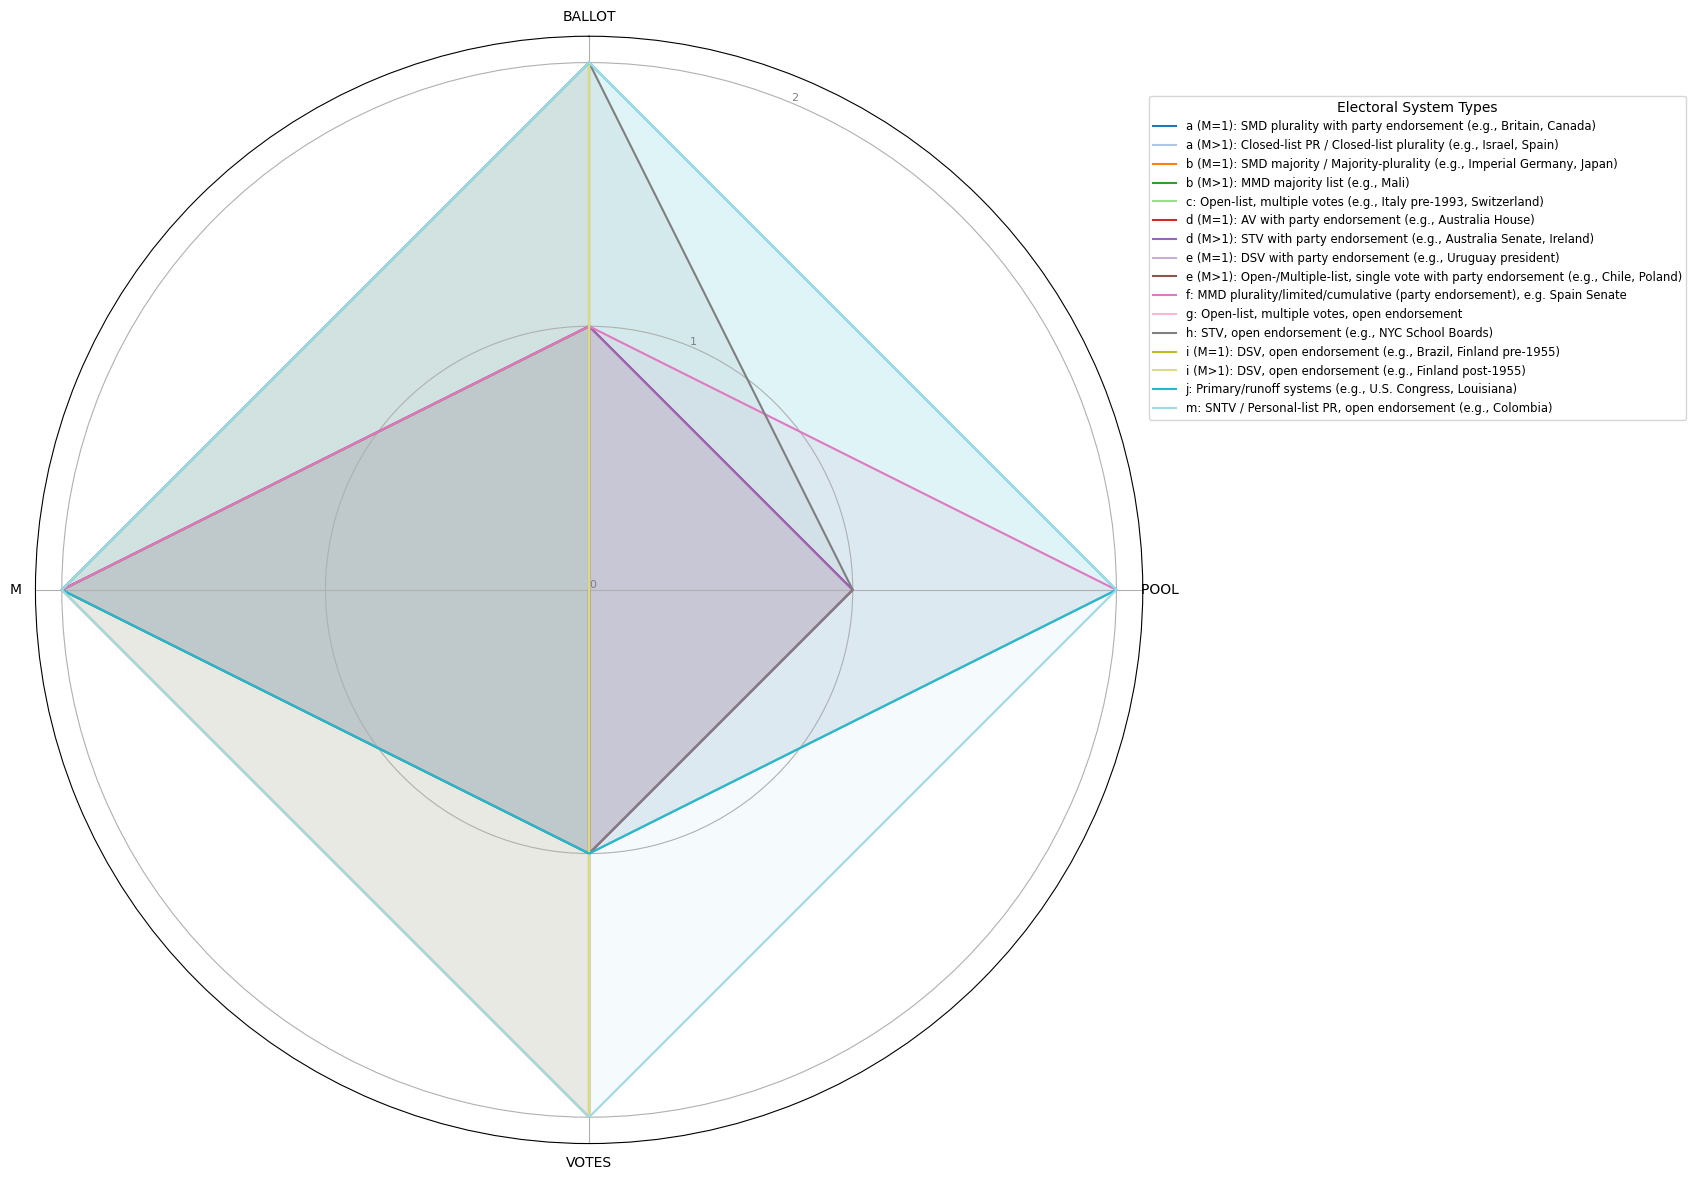

In [13]:
data_expanded = {
    'System': [
        'a (M=1)', 'a (M>1)', 'b (M=1)', 'b (M>1)', 'c', 'd (M=1)', 'd (M>1)',
        'e (M=1)', 'e (M>1)', 'f', 'g', 'h', 'i (M=1)', 'i (M>1)', 'j', 'm'
    ],
    'BALLOT': [
        0, 0, 0, 0, 1, 1, 1,
        1, 1, 1, 2, 2, 2, 2, 2, 2
    ],
    'POOL': [
        0, 0, 0, 0, 0, 1, 1,
        0, 0, 2, 0, 1, 0, 0, 2, 2
    ],
    'VOTES': [
        0, 0, 1, 1, 1, 1, 1,
        2, 2, 1, 1, 1, 2, 2, 1, 2
    ],
    # M is now contextually scaled: 2 if BALLOT > 0 and M > 1, else 0
    'M': [
        0, 0, 0, 0, 2, 0, 2,
        0, 2, 2, 2, 2, 0, 2, 2, 2
    ]
}

# Updated labels
labels = {
    'a (M=1)': "a (M=1): SMD plurality with party endorsement (e.g., Britain, Canada)",
    'a (M>1)': "a (M>1): Closed-list PR / Closed-list plurality (e.g., Israel, Spain)",
    'b (M=1)': "b (M=1): SMD majority / Majority-plurality (e.g., Imperial Germany, Japan)",
    'b (M>1)': "b (M>1): MMD majority list (e.g., Mali)",
    'c':       "c: Open-list, multiple votes (e.g., Italy pre-1993, Switzerland)",
    'd (M=1)': "d (M=1): AV with party endorsement (e.g., Australia House)",
    'd (M>1)': "d (M>1): STV with party endorsement (e.g., Australia Senate, Ireland)",
    'e (M=1)': "e (M=1): DSV with party endorsement (e.g., Uruguay president)",
    'e (M>1)': "e (M>1): Open-/Multiple-list, single vote with party endorsement (e.g., Chile, Poland)",
    'f':       "f: MMD plurality/limited/cumulative (party endorsement), e.g. Spain Senate",
    'g':       "g: Open-list, multiple votes, open endorsement",
    'h':       "h: STV, open endorsement (e.g., NYC School Boards)",
    'i (M=1)': "i (M=1): DSV, open endorsement (e.g., Brazil, Finland pre-1955)",
    'i (M>1)': "i (M>1): DSV, open endorsement (e.g., Finland post-1955)",
    'j':       "j: Primary/runoff systems (e.g., U.S. Congress, Louisiana)",
    'm':       "m: SNTV / Personal-list PR, open endorsement (e.g., Colombia)"
}

# DataFrame and radar setup
df4 = pd.DataFrame(data_expanded)
categories_4d = ['BALLOT', 'POOL', 'VOTES', 'M']
N4 = len(categories_4d)
angles_4d = [n / float(N4) * 2 * pi for n in range(N4)]
angles_4d += angles_4d[:1]

# Plot
fig, ax = plt.subplots(figsize=(16, 14), subplot_kw=dict(polar=True))
cmap = cm.get_cmap('tab20', len(df4))

for i in range(len(df4)):
    values = df4.loc[i, categories_4d].tolist()
    values += values[:1]
    label = labels[df4['System'][i]]
    color = cmap(i)
    ax.plot(angles_4d, values, linewidth=1.5, linestyle='solid', label=label, color=color)
    ax.fill(angles_4d, values, color=color, alpha=0.1)

# Configure plot
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles_4d[:-1])
ax.set_xticklabels(['BALLOT', 'POOL ', 'VOTES', 'M'])  # Adjust POOL spacing
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['0', '1', '2'], color='grey', size=8)
# ax.set_title("Carey & Shugart Electoral System Dimensions (Context-Sensitive M)", size=14)

# Improved legend positioning
plt.legend(loc='center left', bbox_to_anchor=(1, 0.8), fontsize='small', title="Electoral System Types")

plt.tight_layout()
plt.show()